# Importation des données

In [50]:
import pandas as pd
pd.set_option('display.max_rows', 500)
import numpy as np
import matplotlib.pyplot as plt

import requests
from bs4 import BeautifulSoup
import os
import s3fs
import ast
import json


from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score,root_mean_squared_error

In [23]:
os.environ['AWS_S3_ENDPOINT']
S3_ENDPOINT_URL = 'http://' + os.environ['AWS_S3_ENDPOINT']
fs = s3fs.S3FileSystem(client_kwargs = {'endpoint_url' :S3_ENDPOINT_URL })
fs.ls('mlepennec-ensae')
BUCKET = 'mlepennec-ensae'
FILE_OUT_S3 = '/X_train.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    X_train = pd.read_csv(f_out)

In [24]:
FILE_OUT_S3 = '/y_train.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    y_train = pd.read_csv(f_out)

In [25]:
FILE_OUT_S3 = '/X_test.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    X_test = pd.read_csv(f_out)

In [26]:
FILE_OUT_S3 = '/y_test.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    y_test = pd.read_csv(f_out)

In [27]:
FILE_OUT_S3 = '/weights_train.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    weights_train = pd.read_csv(f_out)

In [28]:
FILE_OUT_S3 = '/weights_test.csv'  # Chemin dans le bucket
FILE_OUT_PATH = BUCKET + FILE_OUT_S3       # Chemin complet S3

with fs.open(FILE_OUT_PATH, mode='rb') as f_out:
    weights_test = pd.read_csv(f_out)

In [29]:
X_train=X_train.iloc[:,1:]
X_test=X_test.iloc[:,1:]
y_train=np.array(y_train)[:, 0]
y_test=np.array(y_test)[:, 0]
weights_train=np.log1p(np.array(weights_train)[:, 0])
weights_test=np.log1p(np.array(weights_test)[:, 0])

In [30]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),         # transforme les données
    columns=X_train.columns,               # garde les mêmes noms de colonnes
    index=X_train.index                    # garde les mêmes index
)
X_test_scaled = pd.DataFrame(
    scaler.fit_transform(X_test),         # transforme les données
    columns=X_test.columns,               # garde les mêmes noms de colonnes
    index=X_test.index                    # garde les mêmes index
)

# Régression linéaire

In [31]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train, sample_weight=weights_train)
y_predict = lr.predict(X_test_scaled)

In [32]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict, sample_weight=weights_test))
print('MAE : ',mean_absolute_error(y_test, y_predict, sample_weight=weights_test))
print('R2 : ', r2_score(y_test, y_predict, sample_weight=weights_test))

RMSE :  0.9471269230952145
MAE :  0.7309835964511331
R2 :  0.1952678969113706


# Random Forest

## Random Forest simple

In [33]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled, y_train, sample_weight=weights_train)
y_predict = rf.predict(X_test_scaled)

In [34]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict, sample_weight=weights_test))
print('MAE : ',mean_absolute_error(y_test, y_predict, sample_weight=weights_test))
print('R2 : ', r2_score(y_test, y_predict, sample_weight=weights_test))

RMSE :  0.8783050530478901
MAE :  0.6796669563593793
R2 :  0.3079687194741345


## Tuning Random Forest

In [49]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [None, 10, 20, 50, 100],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                     # cross-validation 5 folds
    scoring='r2',  # pour régression
    n_jobs=-1                  # paralléliser
)

grid_search.fit(X_train_scaled, y_train, sample_weight=weights_train)

# Meilleur modèle
best_model = grid_search.best_estimator_
print("Meilleurs paramètres :",grid_search.best_params_)

# RMSE moyen sur CV
best_r2 = grid_search.best_score_   # MSE est retourné négatif par scikit-learn
print("Meilleur RMSE (CV) :", best_r2)

# RMSE sur le test set
y_pred = best_model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred, sample_weight=weights_test))
print("RMSE sur test set :", test_rmse)

test_mae = mean_absolute_error(y_test, y_pred, sample_weight=weights_test)
print("MAE sur test set :", test_mae)

test_r2 = r2_score(y_test, y_pred, sample_weight=weights_test)
print("R2 sur test set :", test_r2)

Meilleurs paramètres : {'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 1000}
Meilleur RMSE (CV) : 0.35693308277160485
RMSE sur test set : 0.8509309913263101
MAE sur test set : 0.6571852094617182
R2 sur test set : 0.35043346094151284


# Boosting

## GradientBoosting simple

In [51]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train_scaled, y_train, sample_weight=weights_train)
y_predict = gb.predict(X_test_scaled)

In [52]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict, sample_weight=weights_test))
print('MAE : ',mean_absolute_error(y_test, y_predict, sample_weight=weights_test))
print('R2 : ', r2_score(y_test, y_predict, sample_weight=weights_test))

RMSE :  0.8699405993037529
MAE :  0.671747536015982
R2 :  0.32108694229878987


## Tuning Boosting

In [56]:
gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [200, 500,1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_leaf': [1, 3],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,                     # cross-validation 5 folds
    scoring='r2',  # pour régression
    n_jobs=-1                  # paralléliser
)

grid_search.fit(X_train_scaled, y_train, sample_weight=weights_train)

# Meilleur modèle
best_model = grid_search.best_estimator_
print("Meilleurs paramètres :",grid_search.best_params_)

# RMSE moyen sur CV
best_r2 = grid_search.best_score_   # MSE est retourné négatif par scikit-learn
print("Meilleur RMSE (CV) :", best_r2)

# RMSE sur le test set
y_pred = best_model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred, sample_weight=weights_test))
print("RMSE sur test set :", test_rmse)

test_mae = mean_absolute_error(y_test, y_pred, sample_weight=weights_test)
print("MAE sur test set :", test_mae)

test_r2 = r2_score(y_test, y_pred, sample_weight=weights_test)
print("R2 sur test set :", test_r2)

Meilleurs paramètres : {'learning_rate': 0.01, 'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 1000, 'subsample': 0.8}
Meilleur RMSE (CV) : 0.37356534307164657
RMSE sur test set : 0.8466398164409417
MAE sur test set : 0.6528103228355736
R2 sur test set : 0.3569683628870751


# Réseau de neurones

## Réseau de neurones simple

In [61]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.metrics import r2_score

# Modèle simple
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)  # sortie continue
])

model.compile(optimizer="adam", loss="mse")

# Callback pour R2
class R2Callback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(X_test, verbose=0)
        r2 = r2_score(y_test, y_pred)
        print(f" - val_R2: {r2:.4f}")

# Entraînement
history = model.fit(
    X_train_scaled, y_train, sample_weight=weights_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50
)

# RMSE sur le test
y_pred = model.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred, sample_weight=weights_test))
print("RMSE sur test set :", test_rmse)

test_mae = mean_absolute_error(y_test, y_pred, sample_weight=weights_test)
print("MAE sur test set :", test_mae)

test_r2 = r2_score(y_test, y_pred, sample_weight=weights_test)
print("R2 sur test set :", test_r2)


Epoch 1/50


862/862 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 9.6946 - val_loss: 1.2122
Epoch 2/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3.1335 - val_loss: 1.0688
Epoch 3/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.7388 - val_loss: 1.0490
Epoch 4/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.5947 - val_loss: 0.9880
Epoch 5/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.5351 - val_loss: 0.9795
Epoch 6/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.5100 - val_loss: 1.0717
Epoch 7/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.4618 - val_loss: 1.0106
Epoch 8/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.4145 - val_loss: 1.0068
Epoch 9/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.3714 - val_loss: 0.9672
Epoch 10/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.3354 - val_loss: 0.9731
Epoch 11/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.3244 - val_loss: 0.9496
Epoch 12/50
862/862 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.

In [ ]:
param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.0005, 0.001, 0.005, 0.01],
    'activation': ['relu', 'tanh']
}

search = RandomizedSearchCV(
    estimator=MLPRegressor(max_iter=500),
    param_distributions=param_dist,
    n_iter=15,       # très rapide !
    cv=5,
    scoring='r2',
    n_jobs=-1
)


## Importance des variables

In [15]:
importances = rf.feature_importances_

# Créer un DataFrame pour mieux visualiser
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

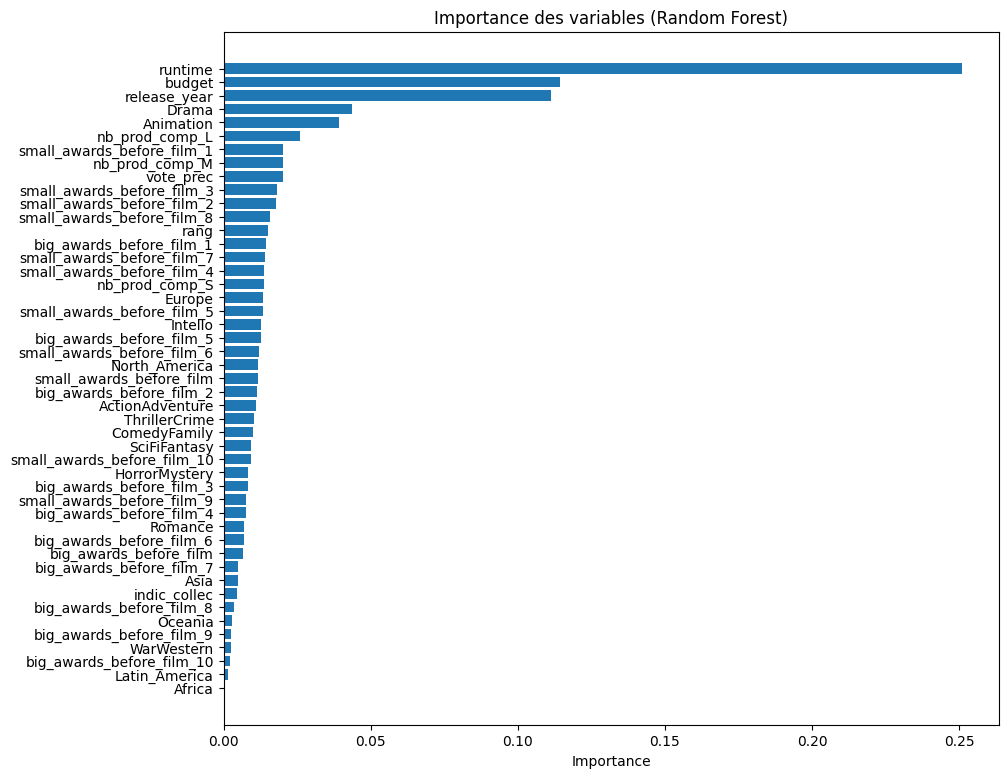

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 9))
plt.barh(feature_importances['Feature'], feature_importances['Importance'])
plt.gca().invert_yaxis()  # Pour avoir la plus importante en haut
plt.xlabel("Importance")
plt.title("Importance des variables (Random Forest)")
plt.show()


In [30]:
selection_variables=list(feature_importances.iloc[:-10,0])

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_scaled[selection_variables], y_train, sample_weight=np.array(weights_train)[:, 0])
y_predict = rf.predict(X_test_scaled[selection_variables])

/opt/python/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [27]:
print('RMSE : ',root_mean_squared_error(y_test, y_predict))
print('MAE : ',mean_absolute_error(y_test, y_predict))
print('R2 : ', r2_score(y_test, y_predict))

RMSE :  0.9294442549348539
MAE :  0.7099511115657923
R2 :  0.303385984441499


## Permutation importance

In [54]:
from sklearn.inspection import permutation_importance

model = RandomForestRegressor(random_state=42)
model.fit(X_train_scaled, y_train, sample_weight=np.array(weights_train)[:, 0])

perm = permutation_importance(model, X_train_scaled, y_train, n_repeats=10, random_state=42)
importances = pd.Series(perm.importances_mean, index=X_train.columns)
ranking = importances.sort_values(ascending=False)


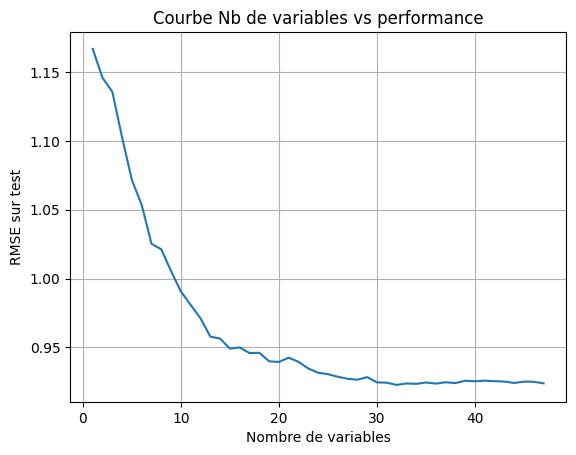

In [55]:
scores = []
features_ordered = ranking.index.tolist()

for k in range(1, len(features_ordered)+1):
    selected_features = features_ordered[:k]
    
    # Subset des données
    X_train_k = X_train_scaled[selected_features]
    X_test_k  = X_test_scaled[selected_features]
    
    # Entraîner un nouveau modèle
    model_k = model.__class__(**model.get_params())  # clone du modèle
    model_k.fit(X_train_k, y_train, sample_weight=np.array(weights_train)[:, 0])
    
    # Performance
    y_pred = model_k.predict(X_test_k)
    score = root_mean_squared_error(y_test, y_pred)
    
    scores.append(score)

import matplotlib.pyplot as plt

plt.plot(range(1, len(scores)+1), scores)
plt.xlabel("Nombre de variables")
plt.ylabel("RMSE sur test")
plt.title("Courbe Nb de variables vs performance")
plt.grid(True)
plt.show()


In [56]:
index_min = scores.index(min(scores))
index_min

ranking=pd.DataFrame(ranking)
ranking['variable'] = ranking.index
selection_variables = list(ranking.iloc[index_min:,:].variable)